# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [99]:
#DEFINE PROJECT

project_link = "https://www.kaggle.com/competitions/widsdatathon2024-challenge1/data"

print("WiDS Datathon 2024: Metastatic Cancer Prediction")
print("Project Link:", project_link)

print("""
Goal:
Predict whether a patient will be diagnosed with metastatic cancer within 90 days.
This is a binary classification task evaluated using ROC AUC.

Dataset:
- Demographics
- Diagnosis codes
- Clinical indicators
- Environmental exposure (Ozone, PM2.5, NO2)
- Socioeconomic indicators
- Target: DiagPeriodL90D (0 = no cancer, 1 = metastatic cancer)
""")


WiDS Datathon 2024: Metastatic Cancer Prediction
Project Link: https://www.kaggle.com/competitions/widsdatathon2024-challenge1/data

Goal:
Predict whether a patient will be diagnosed with metastatic cancer within 90 days.
This is a binary classification task evaluated using ROC AUC.

Dataset:
- Demographics
- Diagnosis codes
- Clinical indicators
- Environmental exposure (Ozone, PM2.5, NO2)
- Socioeconomic indicators
- Target: DiagPeriodL90D (0 = no cancer, 1 = metastatic cancer)



In [97]:
#IMPORT LIBRARIES

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")


In [96]:
#DATA LOADING & INITIAL LOOK

df = pd.read_csv("training.csv")
tdf = pd.read_csv("test.csv")

print("Training shape:", df.shape)
print("Test shape:", tdf.shape)

df.head()


Training shape: (12906, 83)
Test shape: (5792, 82)


,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,475714,NaN,MEDICAID,CA,924,84,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,349367,White,COMMERCIAL,CA,928,62,F,28.49,C50411,Malig neoplm of upper-outer quadrant of right ...,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,138632,White,COMMERCIAL,TX,760,43,F,38.09,C50112,Malignant neoplasm of central portion of left ...,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,617843,White,COMMERCIAL,CA,926,45,F,NaN,C50212,Malig neoplasm of upper-inner quadrant of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,817482,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0


In [72]:
#MISSING VALUES + FEATURE SUMMARY

print("Missing values per feature:")
print(df.isna().sum().sort_values(ascending=False))

summary = []
for col in df.columns:
    col_type = "Numerical" if pd.api.types.is_numeric_dtype(df[col]) else "Categorical"
    missing = df[col].isna().sum()
    if col_type == "Numerical":
        values = f"{df[col].min()} to {df[col].max()}"
    else:
        values = ", ".join(df[col].astype(str).unique()[:5])
    summary.append([col, col_type, values, missing])

pd.DataFrame(summary, columns=["Feature", "Type", "Values/Range", "Missing"])


Missing values per feature:
metastatic_first_novel_treatment_type    12882
metastatic_first_novel_treatment         12882
bmi                                       8965
patient_race                              6385
payer_type                                1803
                                         ...  
patient_zip3                                 0
breast_cancer_diagnosis_desc                 0
metastatic_cancer_diagnosis_code             0
patient_id                                   0
DiagPeriodL90D                               0
Length: 83, dtype: int64


,Feature,Type,Values/Range,Missing
0,patient_id,Numerical,100063 to 999896,0
1,patient_race,Categorical,"nan, White, Other, Hispanic, Asian",6385
2,payer_type,Categorical,"MEDICAID, COMMERCIAL, MEDICARE ADVANTAGE, nan",1803
3,patient_state,Categorical,"CA, TX, ID, NY, IL",51
4,patient_zip3,Numerical,101 to 999,0
...,...,...,...,...
78,veteran,Numerical,1.2 to 25.2,1
79,Ozone,Numerical,30.93931639 to 52.23720962,29
80,PM25,Numerical,2.636008213 to 11.16940832,29
81,N02,Numerical,2.760370724 to 31.50477477,29


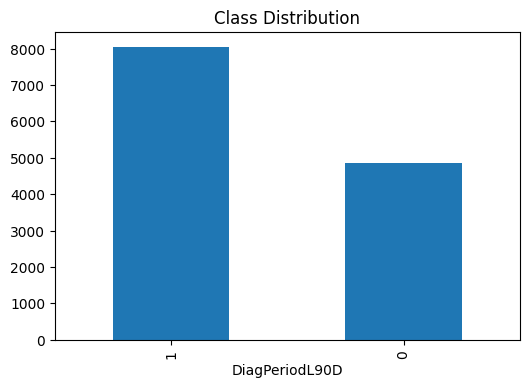

In [73]:
#CLASS DISTRIBUTION


df["DiagPeriodL90D"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Class Distribution")
plt.show()


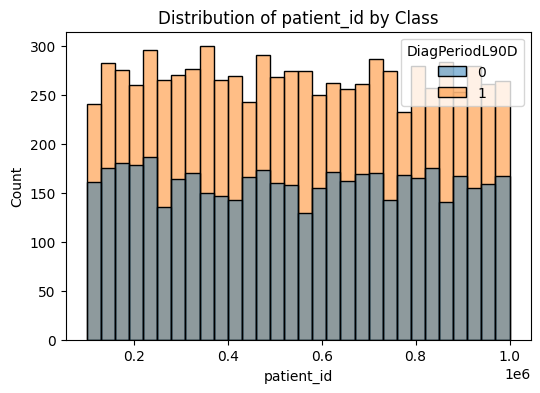

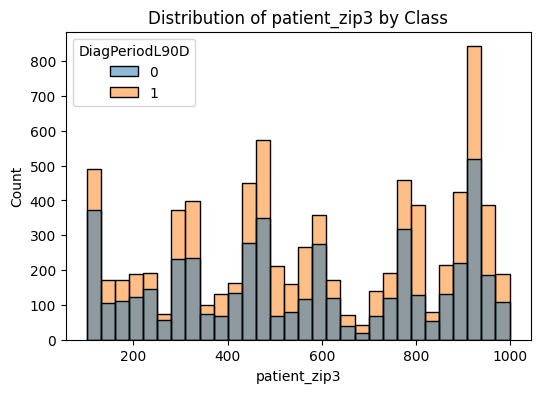

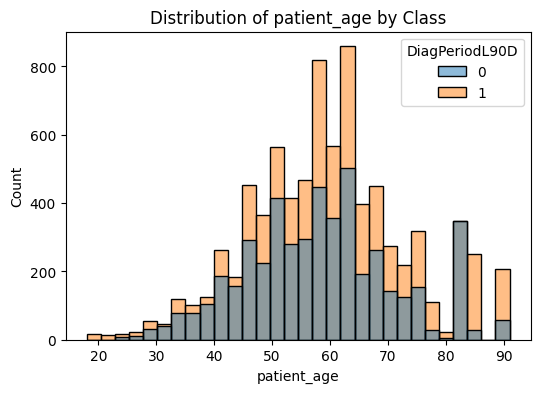

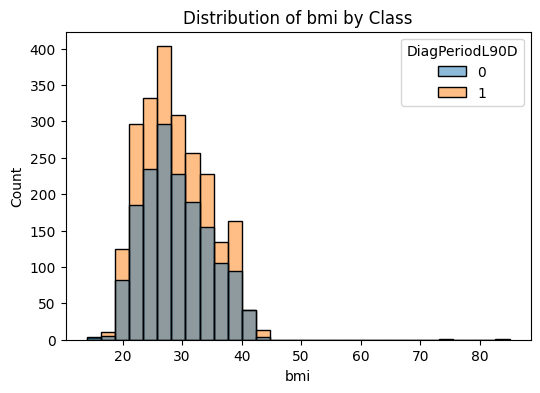

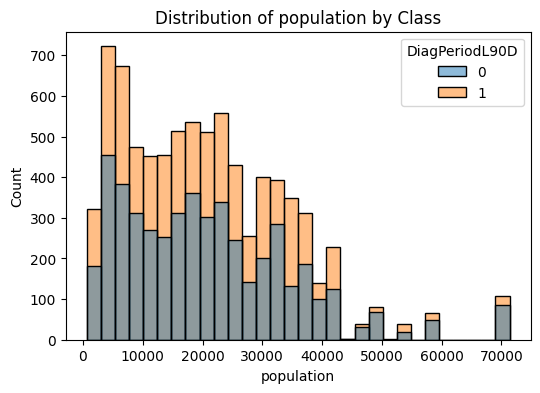

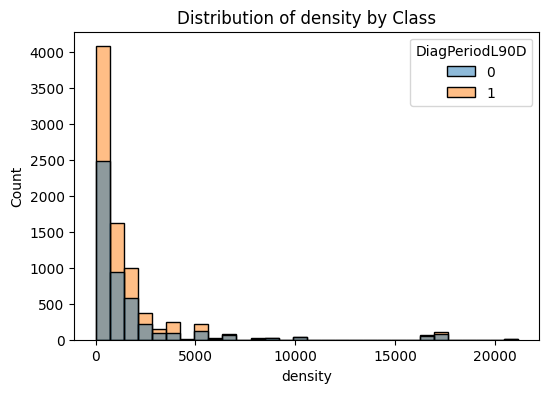

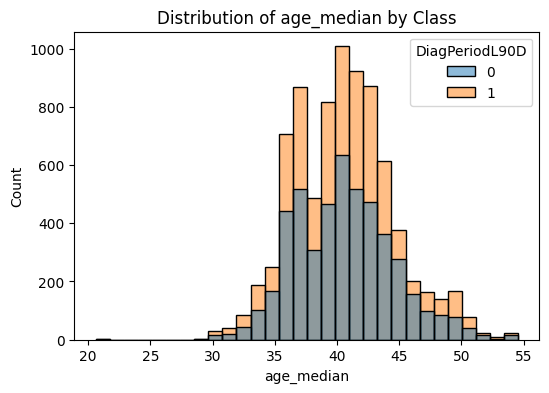

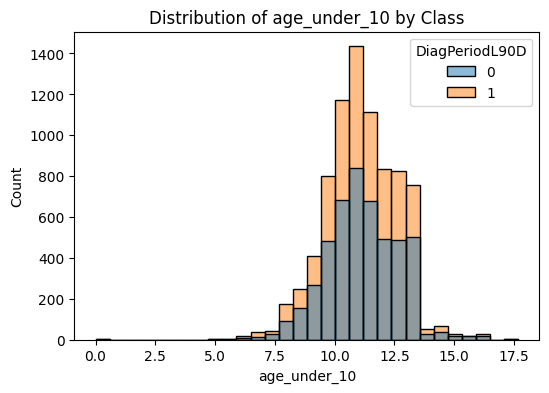

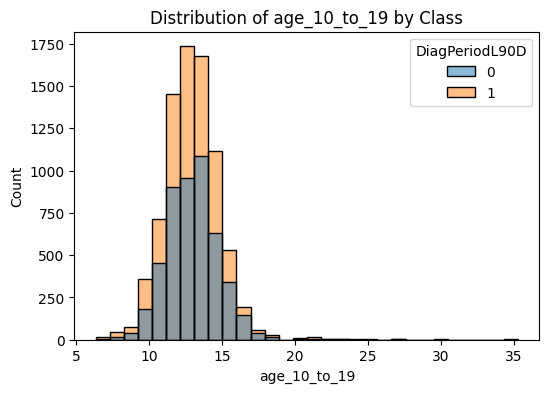

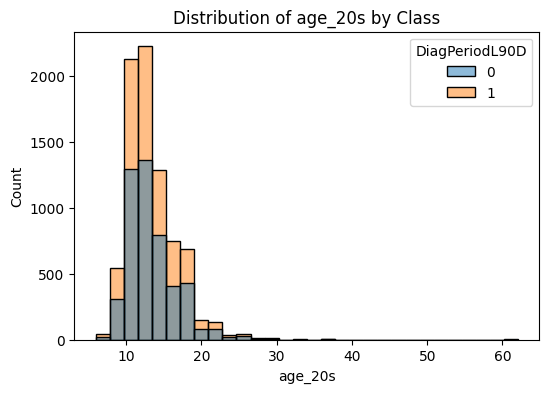

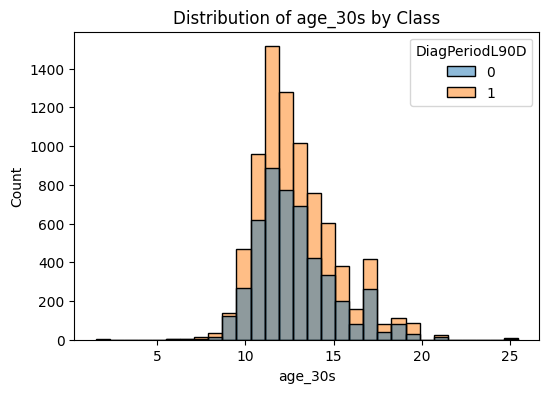

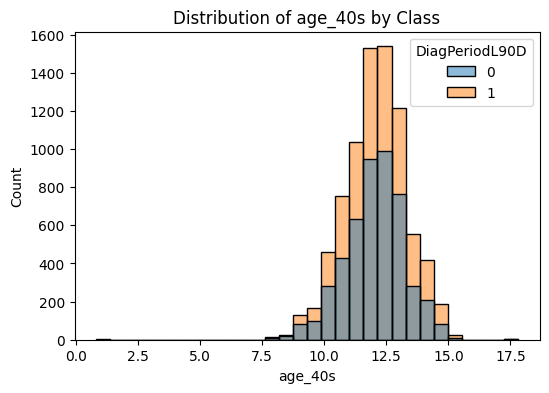

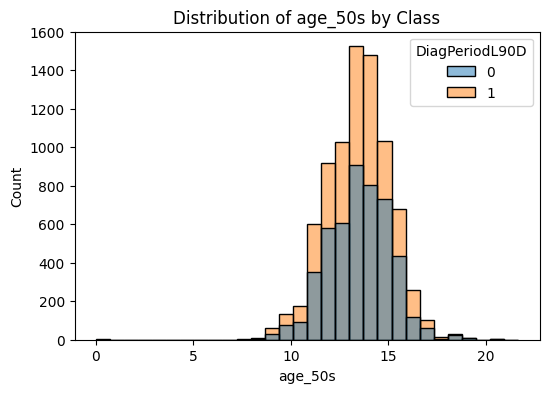

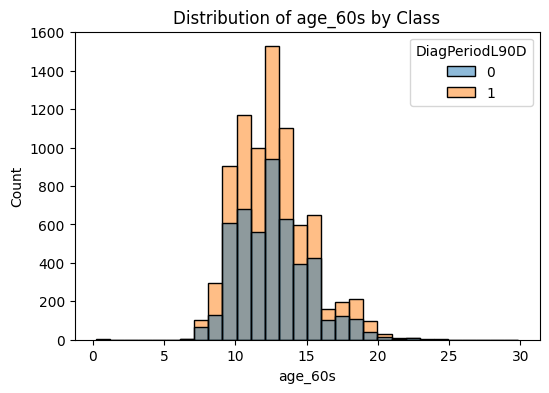

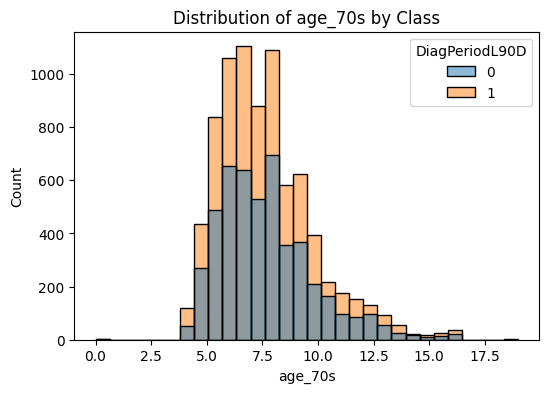

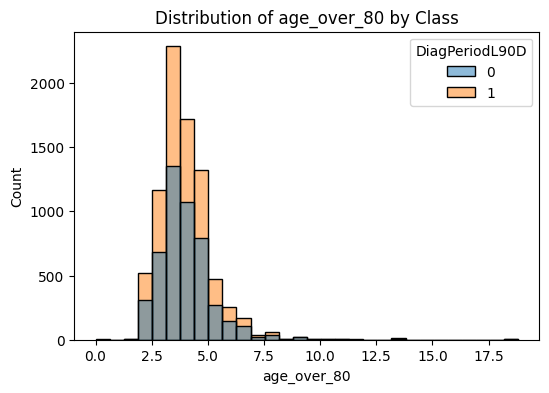

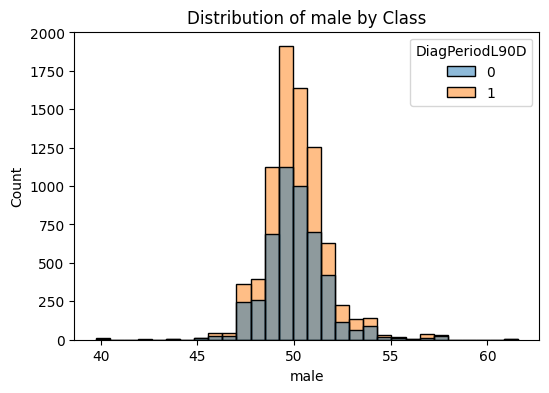

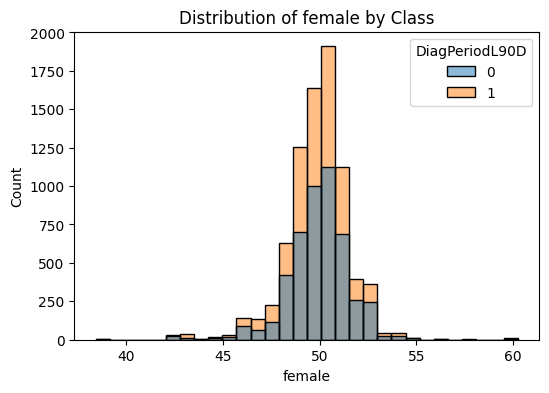

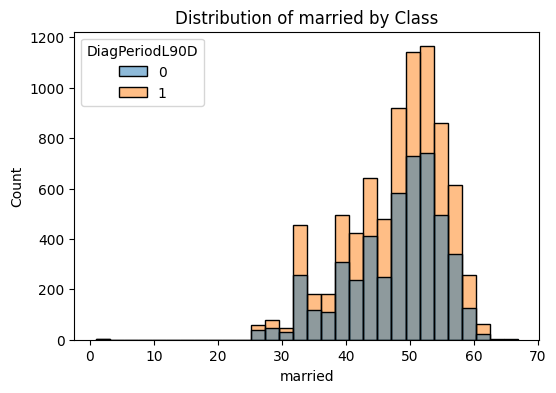

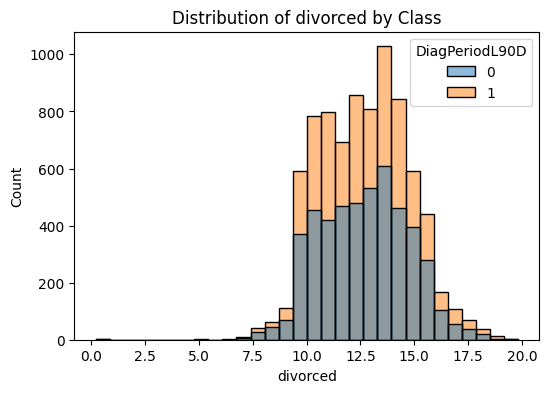

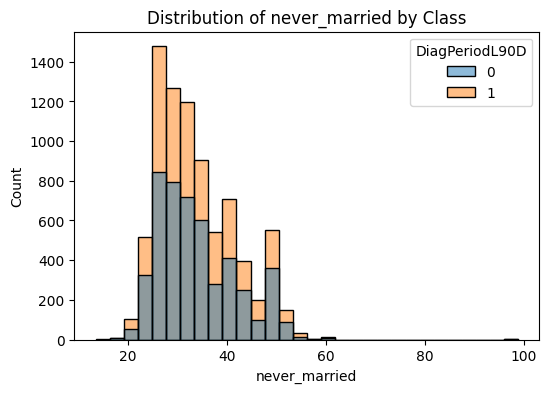

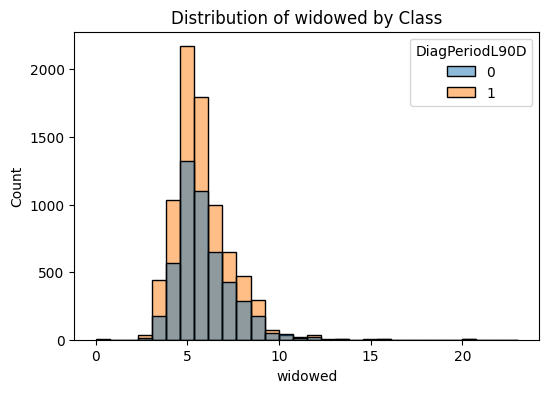

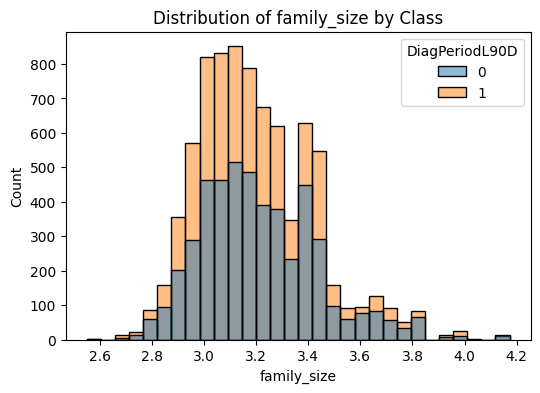

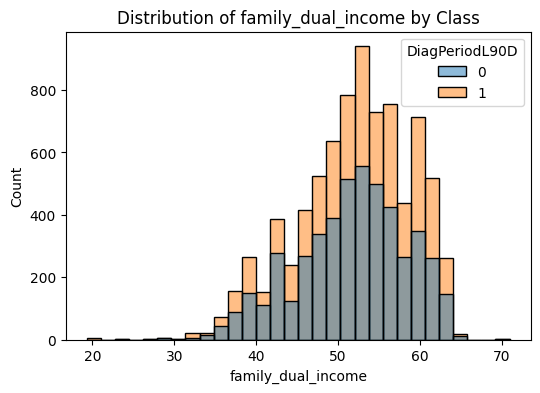

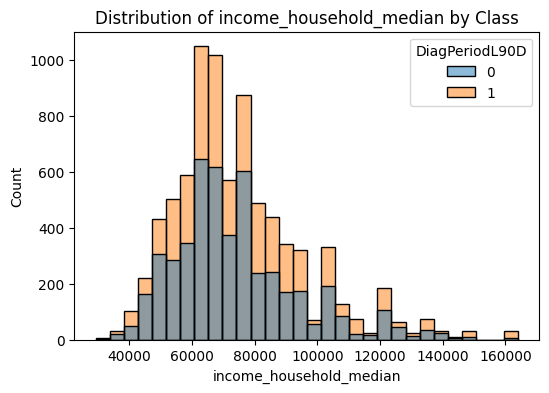

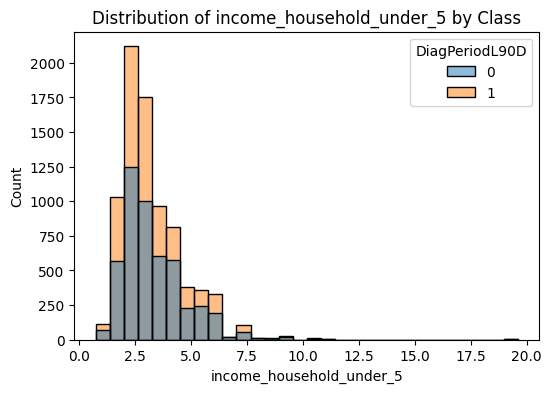

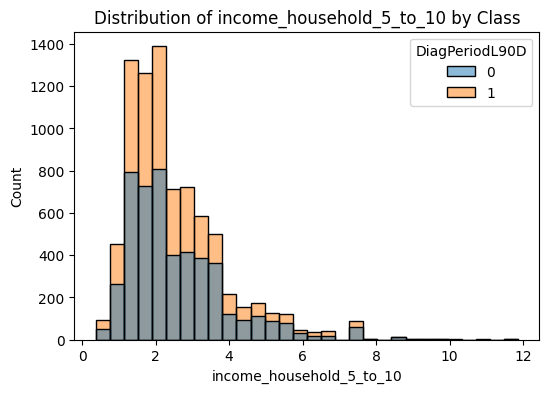

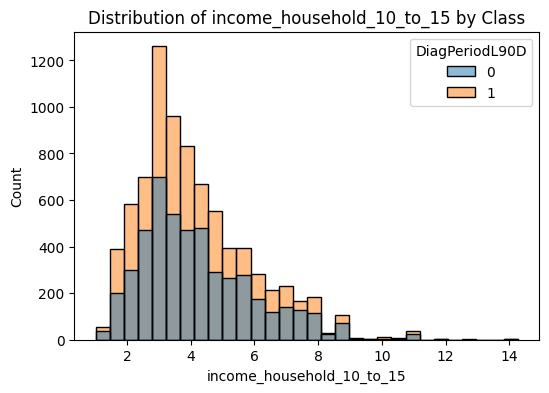

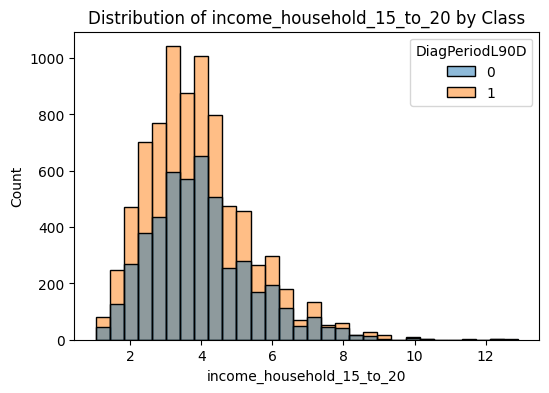

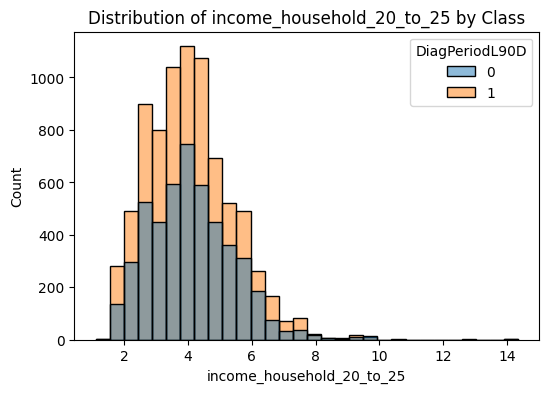

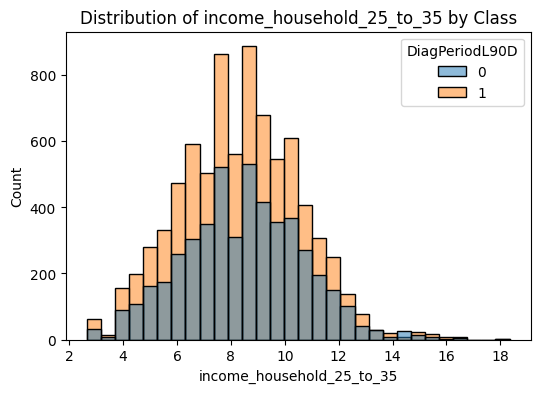

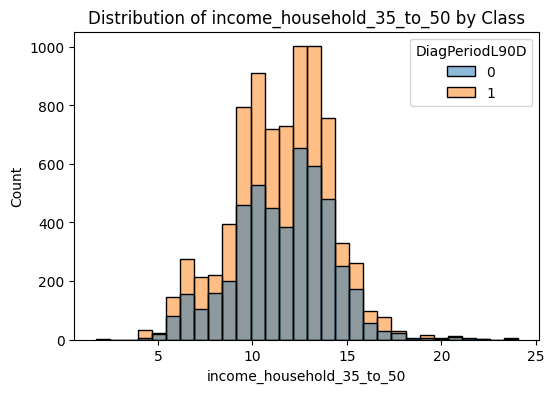

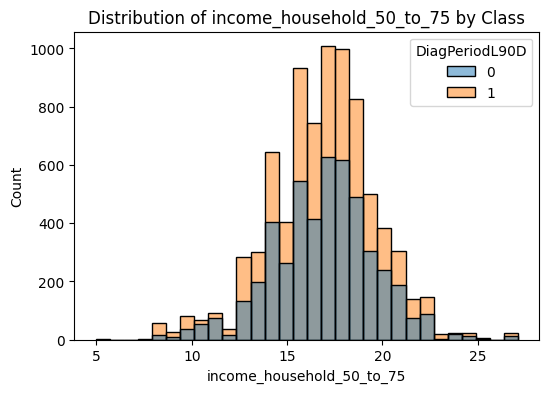

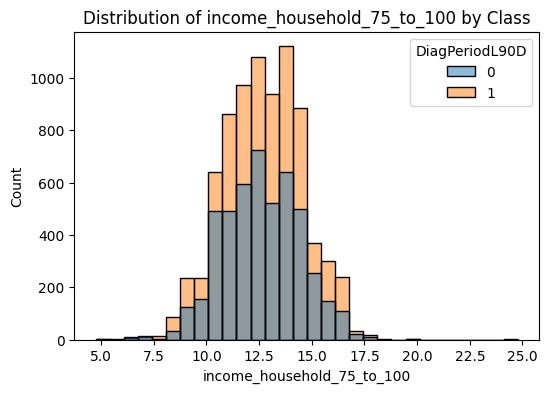

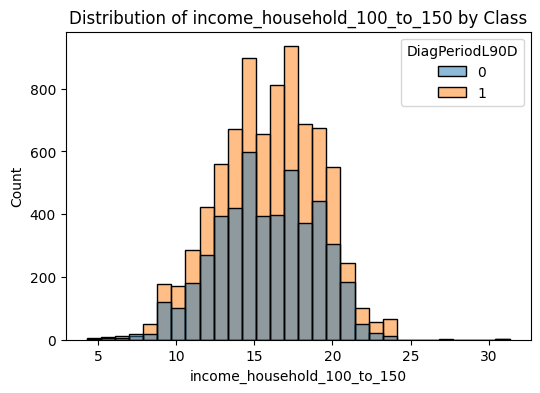

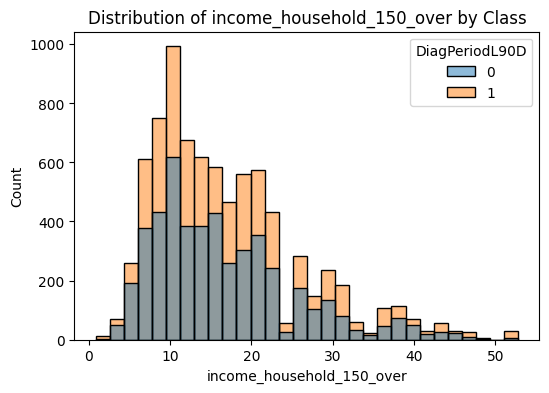

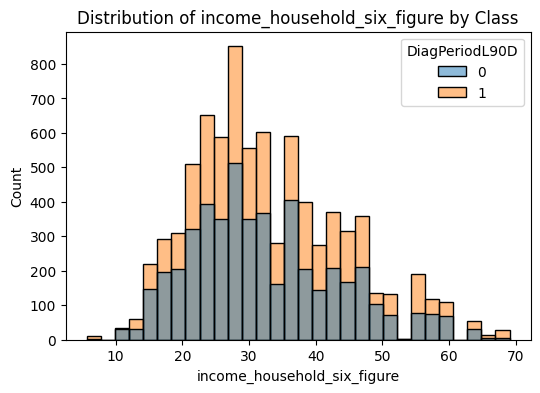

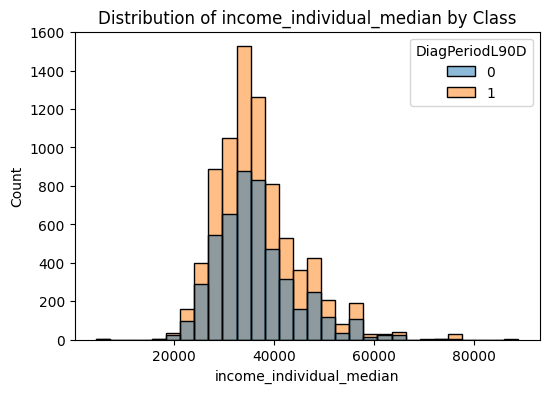

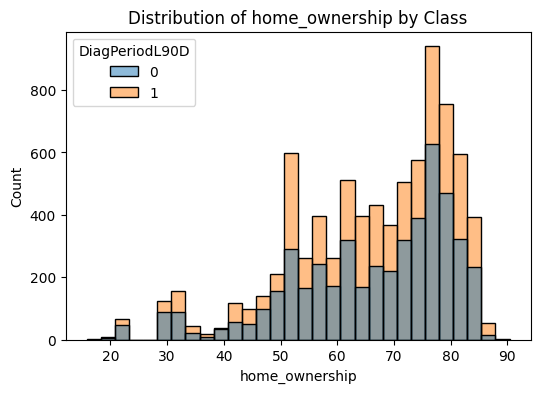

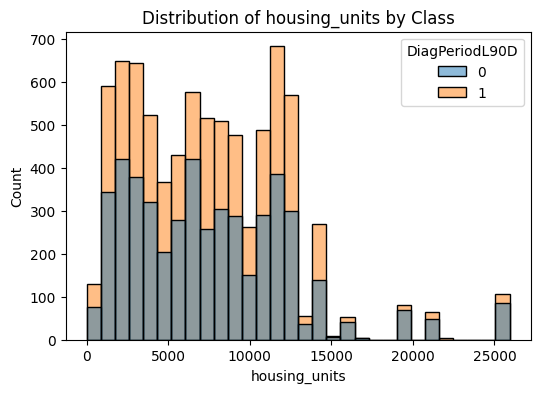

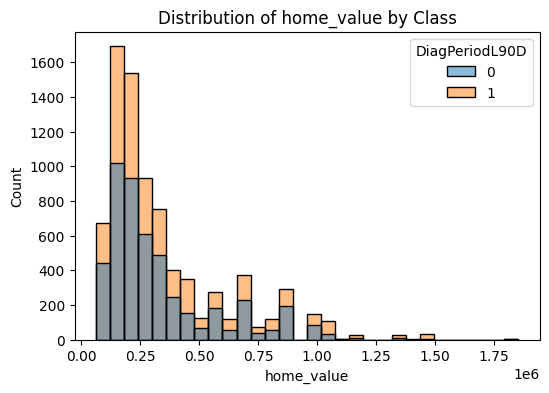

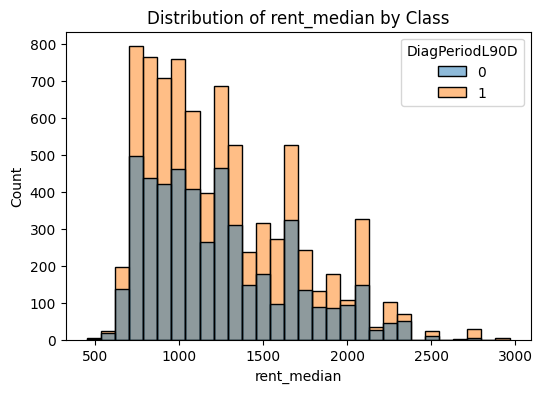

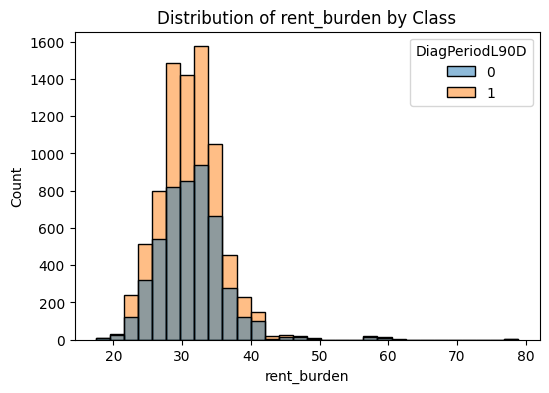

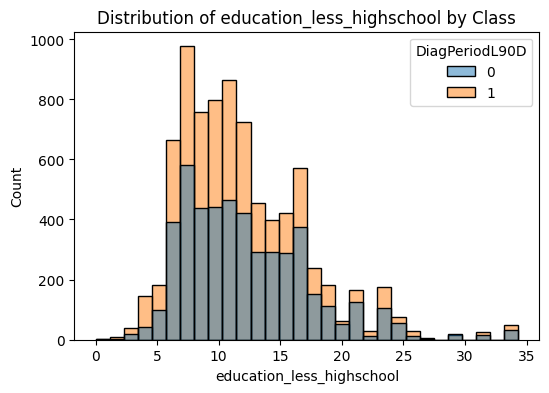

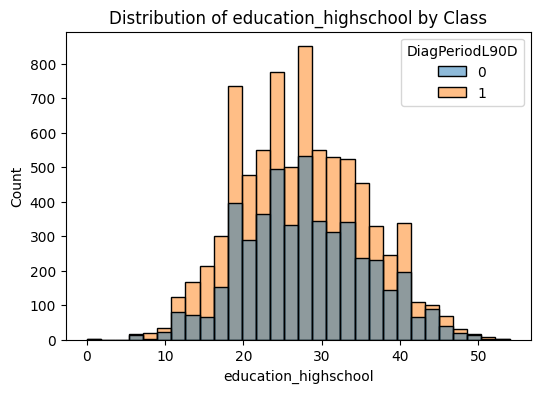

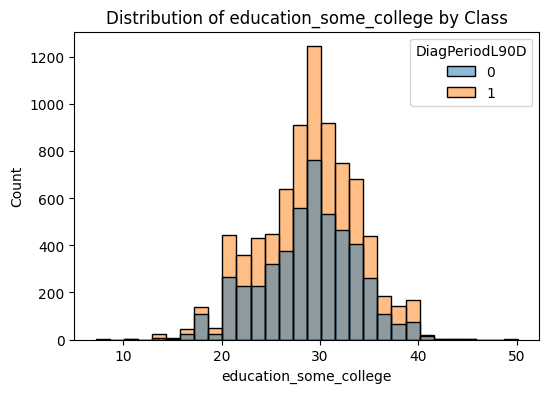

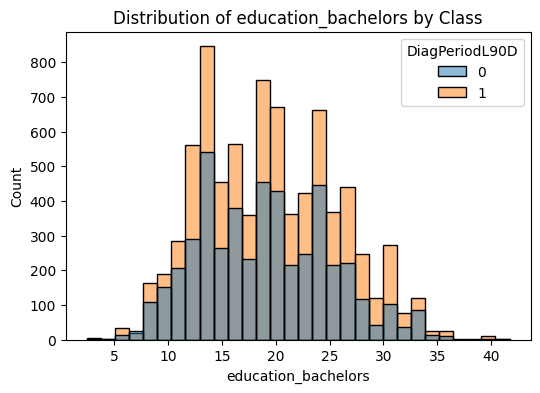

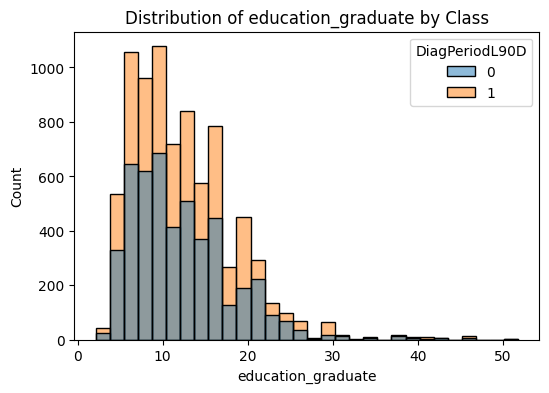

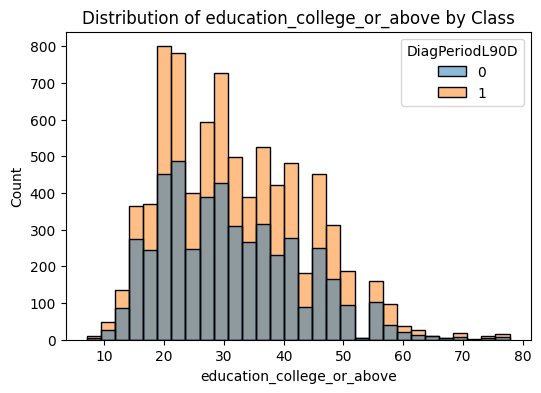

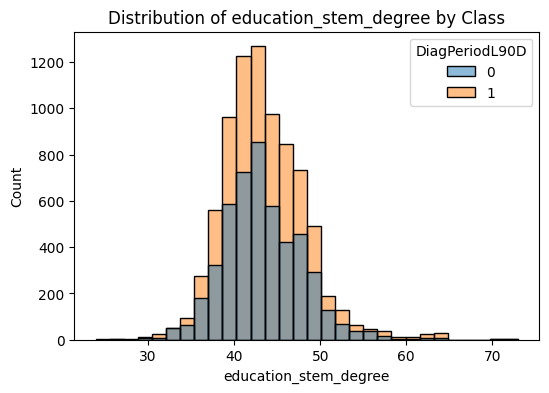

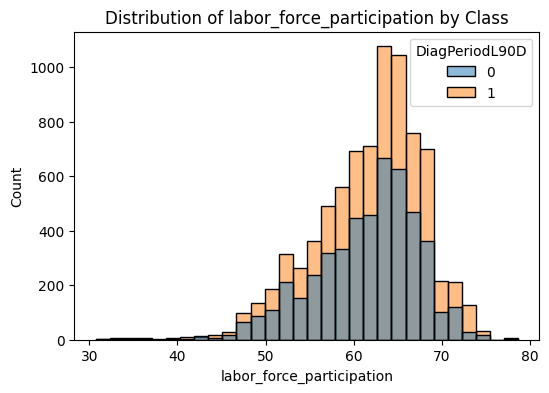

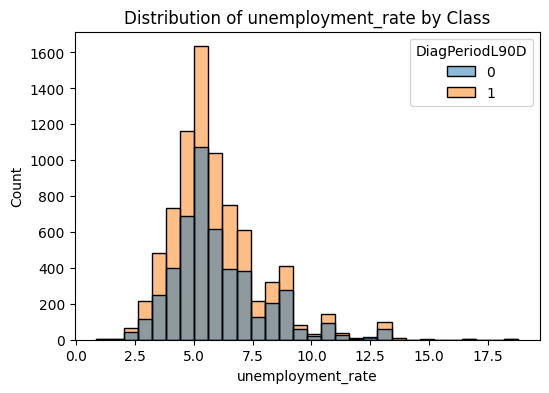

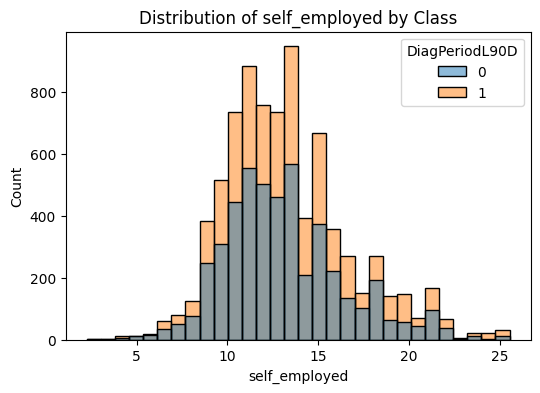

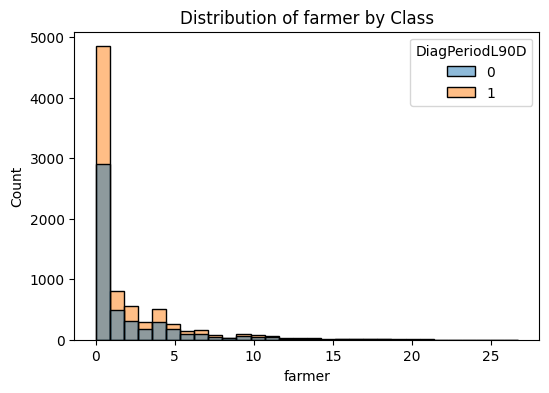

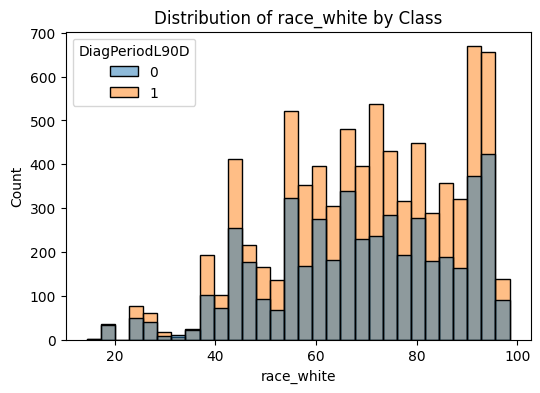

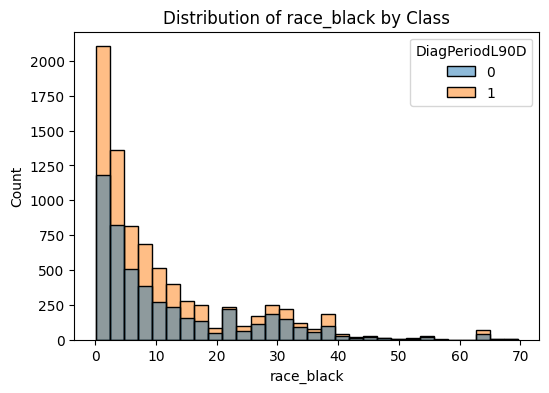

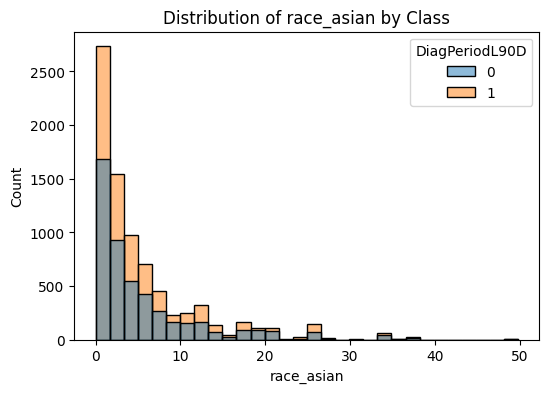

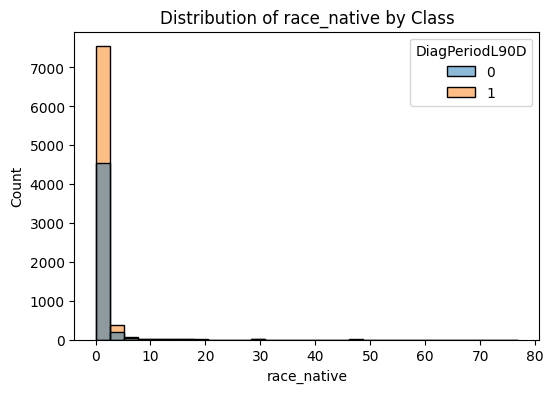

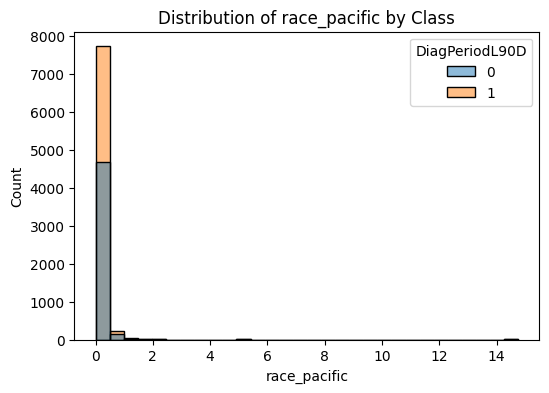

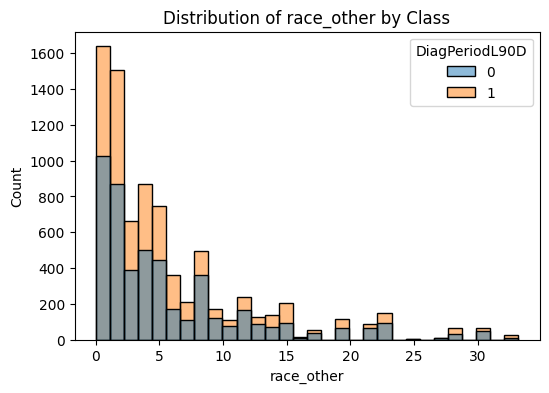

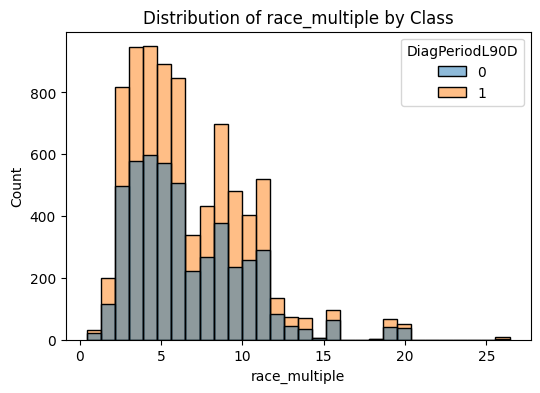

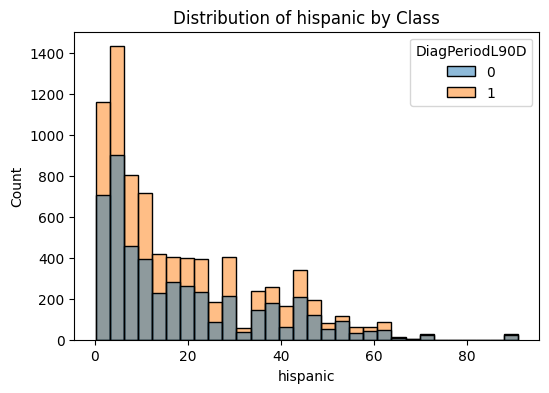

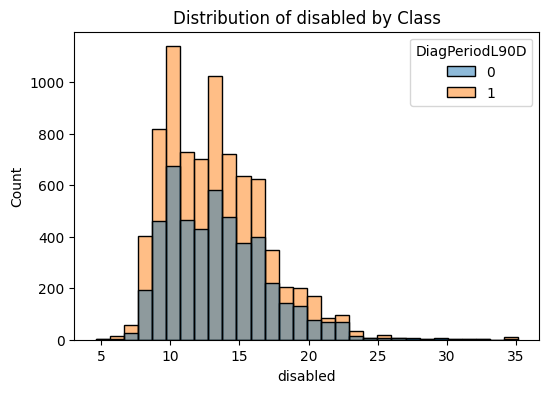

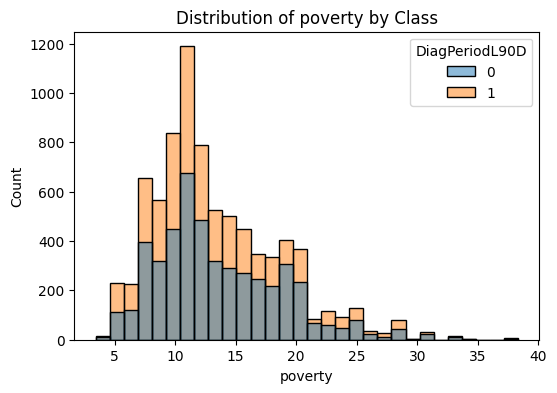

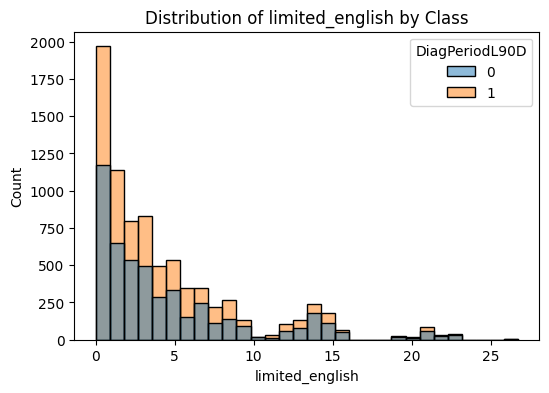

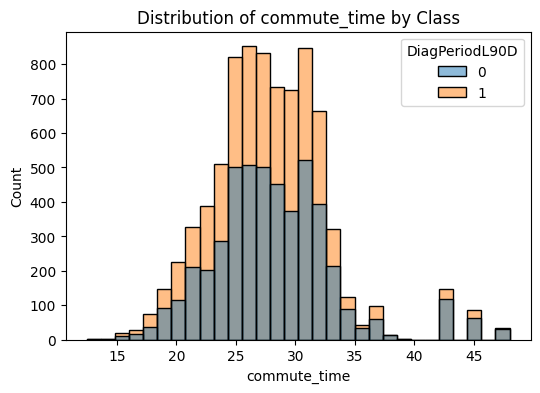

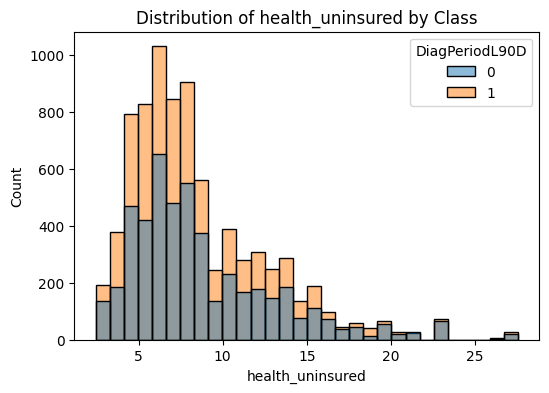

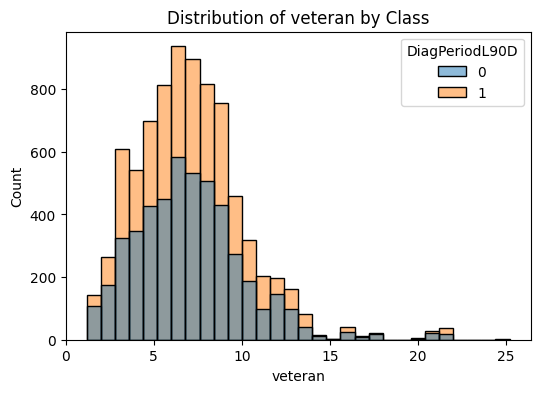

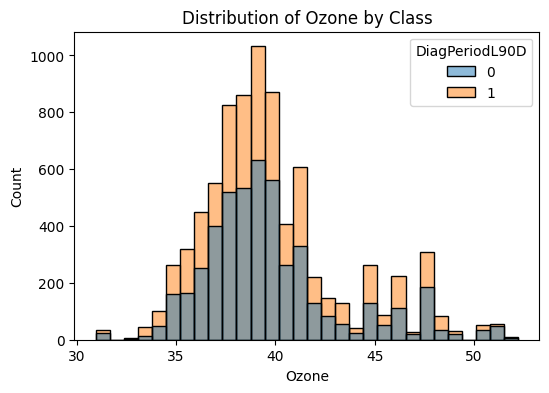

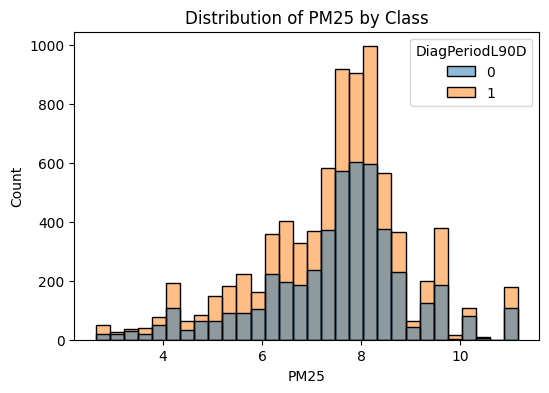

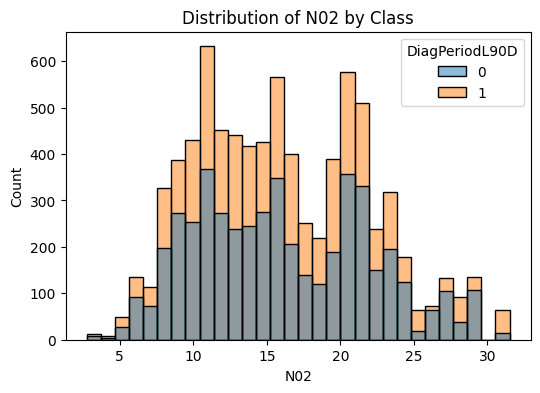

In [74]:
#HISTOGRAMS BY CLASS

num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    if col == "DiagPeriodL90D":
        continue
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="DiagPeriodL90D", kde=False, bins=30)
    plt.title(f"Distribution of {col} by Class")
    plt.show()


In [75]:
#FEATURE ENGINEERING

# Pollutant interaction
df["pollution"] = df["N02"] * df["Ozone"] * df["PM25"]
tdf["pollution"] = tdf["N02"] * tdf["Ozone"] * tdf["PM25"]

# Female indicator
df["is_female"] = df.breast_cancer_diagnosis_desc.str.contains("female", case=False).astype(int)
tdf["is_female"] = tdf.breast_cancer_diagnosis_desc.str.contains("female", case=False).astype(int)


In [76]:
#DROP NON-USEFUL COLUMNS

drop_cols = ["patient_id", "breast_cancer_diagnosis_code"]
df = df.drop(columns=[c for c in drop_cols if c in df], errors="ignore")
tdf = tdf.drop(columns=[c for c in drop_cols if c in tdf], errors="ignore")


In [77]:
#ONE-HOT ENCODING

df = pd.get_dummies(df, drop_first=True)
tdf = pd.get_dummies(tdf, drop_first=True)

df, tdf = df.align(tdf, join="left", axis=1, fill_value=0)


In [78]:
#SCALING

scaler = StandardScaler()

num_cols = df.select_dtypes(include=["int64","float64"]).columns
num_cols = [c for c in num_cols if c != "DiagPeriodL90D"]

df[num_cols] = scaler.fit_transform(df[num_cols])
tdf[num_cols] = scaler.transform(tdf[num_cols])


In [85]:
#TRAIN/VALIDATION SPLIT


X = df.drop(columns=["DiagPeriodL90D"])
y = df["DiagPeriodL90D"]

feature_cols = X.columns  

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [88]:
#TRAIN LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

#Define X and y
X = df.drop(columns=["DiagPeriodL90D"])
y = df["DiagPeriodL90D"]

#Save feature columns for evaluation and submission
feature_cols = X.columns

#Train/validation split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert everything to numeric
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_val   = X_val.apply(pd.to_numeric, errors="coerce")

#Replace any remaining NaNs with 0
X_train = X_train.fillna(0)
X_val   = X_val.fillna(0)

#Train Logistic Regression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


Validation Accuracy: 0.8059643687064292
Validation AUC: 0.7821135299685349

Confusion Matrix:
 [[ 538  432]
 [  69 1543]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.55      0.68       970
           1       0.78      0.96      0.86      1612

    accuracy                           0.81      2582
   macro avg       0.83      0.76      0.77      2582
weighted avg       0.82      0.81      0.79      2582



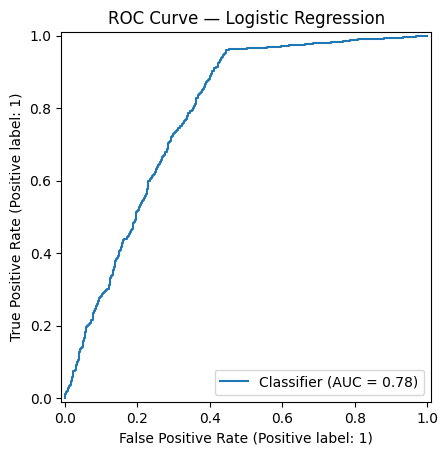

In [90]:
# EVALUATION 

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay

#Recreate feature_cols safely 
feature_cols = [col for col in X_train.columns]

#Ensure X_val uses the same columns and order
X_val_eval = X_val.reindex(columns=feature_cols, fill_value=0)

#Predict
val_probs = model.predict_proba(X_val_eval)[:, 1]
val_preds = model.predict(X_val_eval)

#Metrics
print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("Validation AUC:", roc_auc_score(y_val, val_probs))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, val_preds))
print("\nClassification Report:\n", classification_report(y_val, val_preds))

#ROC Curve
RocCurveDisplay.from_predictions(y_val, val_probs)
plt.title("ROC Curve — Logistic Regression")
plt.show()



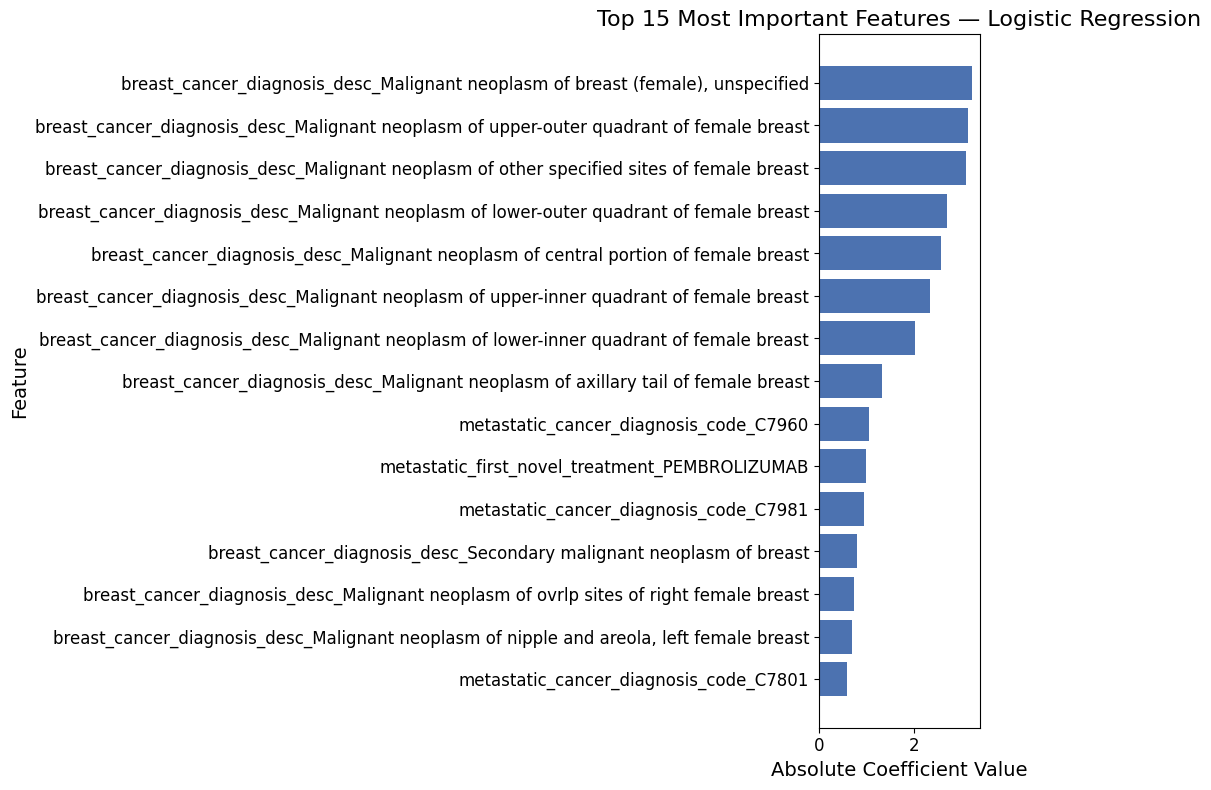

In [94]:
# FEATURE IMPORTANCE 


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Extract coefficients
coefs = model.coef_[0]

#Build dataframe
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": np.abs(coefs)
})

#Sort by importance
importance_df = importance_df.sort_values("importance", ascending=False)

#Plot top 15 
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"][::-1],
         top_features["importance"][::-1],
         color="#4C72B0")

plt.title("Top 15 Most Important Features — Logistic Regression", fontsize=16)
plt.xlabel("Absolute Coefficient Value", fontsize=14)
plt.ylabel("Feature", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()



In [95]:
# KAGGLE SUBMISSION 

# Reload raw test for patient_id
raw_test = pd.read_csv("test.csv")

# Recreate feature columns (
feature_cols = [col for col in X_train.columns]

# Prepare test data
tdf_sub = tdf.copy()

# Drop target column 
if "DiagPeriodL90D" in tdf_sub.columns:
    tdf_sub = tdf_sub.drop(columns=["DiagPeriodL90D"])

# Ensure numeric + fill NaNs
tdf_sub = tdf_sub.apply(pd.to_numeric, errors="coerce").fillna(0)

# Align test columns to training columns
tdf_sub = tdf_sub.reindex(columns=feature_cols, fill_value=0)

# SAFETY CHECK
try:
    _ = model.classes_
except AttributeError:
    print("Model was not fitted — refitting now.")
    model.fit(X_train.fillna(0), y_train)

# Predict probabilities
test_probs = model.predict_proba(tdf_sub)[:, 1]

# Build submission
submission = pd.DataFrame({
    "patient_id": raw_test["patient_id"],
    "DiagPeriodL90D": test_probs
})

submission.to_csv("submission.csv", index=False)
submission.head()


,patient_id,DiagPeriodL90D
0,573710,0.763698
1,593679,0.739950
2,184532,0.746985
3,447383,0.732917
4,687972,0.764128
